# `Matplotlib` 資料視覺化

`matplotlib` 幾乎是標準 Python 畫圖套件了! 在有 `matplotlib` 之前, Python 要畫圖不那麼方便, 和 Python 很多套件一樣, 有許多方案, 但各家有不同的優缺點, 也沒有一套是大家都在用的。

而 `matplotlib` 仿 Matlab 式的畫圖方式, 讓很多人很快入手、並且功能相當完整。原作者是 John D. Hunter, 和很多 Python 的套件作者一樣, 他有博士學位。非常令人遺憾的是他在 2012 年因大腸直腸癌治療併發症過逝, 過逝時才 44 歲!


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 1 畫個函數

前面說過 `plt.plot` 的基本用法是

    plt.plot(X,Y)

其中 X, Y 是分別是點 x 座標, y 座標形的的 list 或 array。

### 【重點】標準函數畫法

函數畫圖其實就是描點法, 而且再次用到陣列導向計算的概念。

我們先牛刀小試, 畫個 $\sin$ 的圖。

$$f(x) = \sin(x)$$

先來設個 x 的範圍, 就 -10 到 10, 給 100 個點。

In [5]:
x=np.linspace(-10,10,100)

y 自然是 $\sin(x)$。

In [6]:
y=np.sin(x)

畫圖!

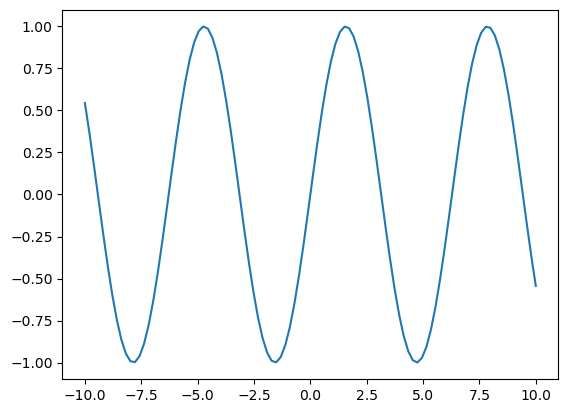

In [7]:
plt.plot(x,y)

### 【練習】函數畫圖

這次我們來畫:

$$f(x) = \frac{\sin(5x)}{1+x^2}$$

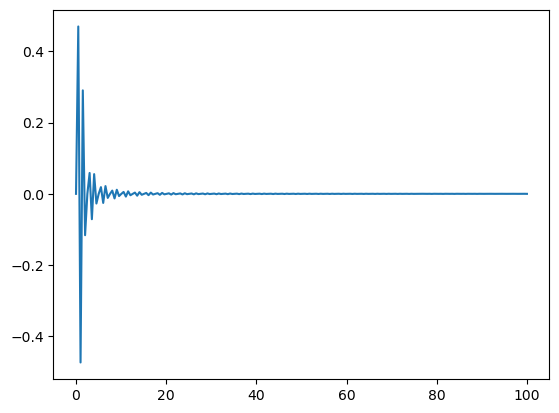

In [8]:
x=np.linspace(0,100,200)
y=np.sin(5*x)/(1+x**2)
plt.plot(x,y)

## 2 快速改變風格

雖然 `matplotlib` 在很辛苦的調校之後也是可以畫美美的圖, 不過它比較是「讓我們快速看到結果」的套件。所以它有些快速基本修飾功能。

### 【技巧】快速改變顏色

![快取色彩](images/color.png)

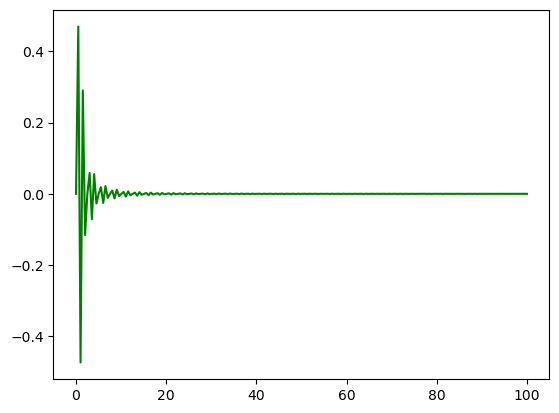

In [9]:
x=np.linspace(0,100,200)
y=np.sin(5*x)/(1+x**2)
plt.plot(x,y,"g")

### 【技巧】快速改變線條風格

快速改變線條風格, 還可和顏色混用。

| 參數 | 說明 |
|---|---|
| `--` | dash |
| `-.` | 點 + dash |
| `:` | 點點 |
| `o` | 大點點 |
| `^` | 三角 |
| `s` | 方塊 |

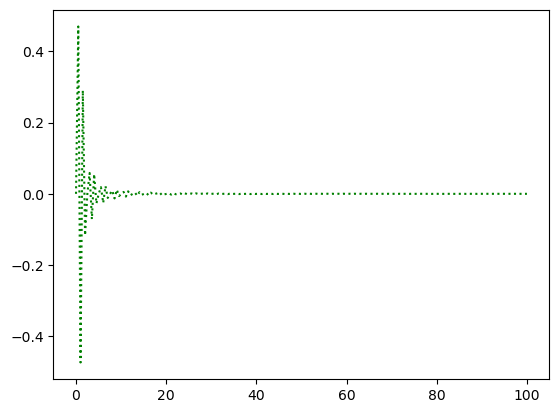

In [10]:
x=np.linspace(0,100,200)
y=np.sin(5*x)/(1+x**2)
plt.plot(x,y,"g:")

## 3 基本的修飾

| 參數 | 說明 |
|---|---|
| `alpha` | 透明度 |
| `color` (`c`)| 顏色 |
| `linestyle` (`ls`) | 線條風格 |
| `linewidth` (`lw`) | 線寬 |

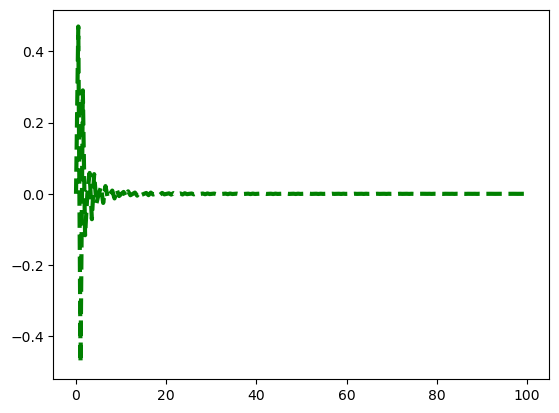

In [11]:
x=np.linspace(0,100,200)
y=np.sin(5*x)/(1+x**2)
plt.plot(x,y,"g--",lw=3)

## 4 如果畫個參數式圖形

其實參數式圖形基本上也是一堆 x, y 的座標, 只是 x(t), y(t) 都是 t 的函數, 我們可以想成 t 是時間。

假設我們的

$$ -2\pi \leq t \leq 2\pi$$

要畫個半徑是 r 的圓, x(t), y(t) 就是這樣:

* $x(t) = r\cos(t)$
* $y(t) = r\sin(t)$

我們來試試事情是不是如我們想的這樣...

In [12]:
r=3
t=np.linspace(-2*np.pi,2*np.pi,200)
#200個點

In [13]:
x=r*np.cos(t)
y=r*np.sin(t)


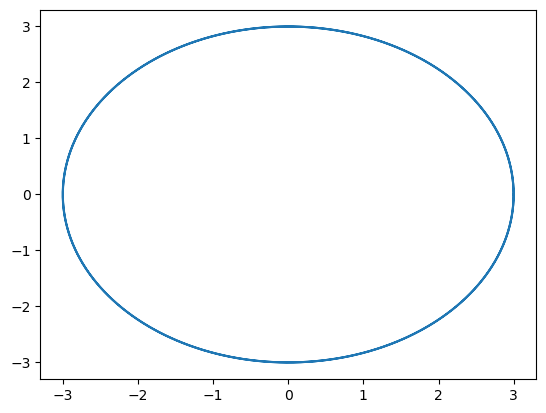

In [14]:
plt.plot(x,y)

真的成功了... 等等, `matplotlib` 怎麼畫成橢圓呢? 我們來調整一下。

'plt.gca()： 這是 "Get Current Axes" (取得當前座標軸) 的縮寫。Matplotlib 其實是由「畫布 (Figure)」和上面的「座標軸 (Axes)」組成的。這行程式碼的意思是：「請把現在正在畫的這塊區域交給我控制！」\n\nax.set_aspect("equal")： 這是幾何畫圖的靈魂！它強制規定 「X 軸的 1 單位長度，必須跟 Y 軸的 1 單位長度在螢幕上看起來一模一樣」（也就是 1:1 等比例）。'

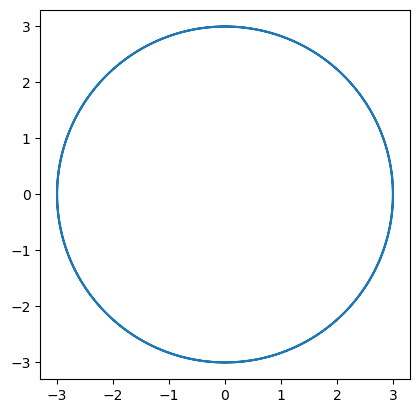

In [15]:
ax=plt.gca()
ax.set_aspect("equal")
plt.plot(x,y)

"""plt.gca()： 這是 "Get Current Axes" (取得當前座標軸) 的縮寫。Matplotlib 其實是由「畫布 (Figure)」和上面的「座標軸 (Axes)」組成的。這行程式碼的意思是：「請把現在正在畫的這塊區域交給我控制！」
ax.set_aspect("equal")： 這是幾何畫圖的靈魂！它強制規定 「X 軸的 1 單位長度，必須跟 Y 軸的 1 單位長度在螢幕上看起來一模一樣」（也就是 1:1 等比例）。"""


再來我們可以想一下, 如果 r 不是故定的呢? 也就是它會變長變短, 是不是會畫出很多特別的圖呢? 其實很多特別的曲線不過就是找個試合的 r(t), 我們來隨意試試看。

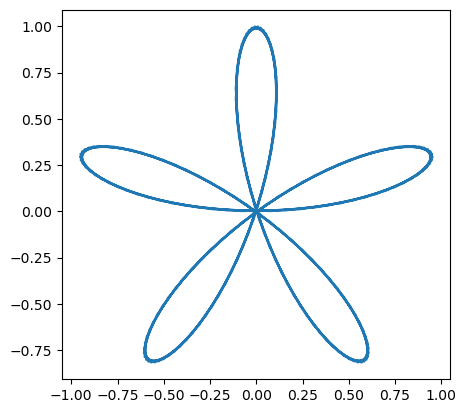

In [16]:
r=np.sin(5*t)
x=r*np.cos(t)
y=r*np.sin(t)
ax=plt.gca()
ax.set_aspect("equal")
plt.plot(x,y)

是不是很有意思呢? 你也可以自己試試不同的變化。

## 5 `subplot` 畫多個圖

我們每次畫圖的時候, `matplotlib` 就弄 1 個 figure 畫圖區出來, 裡面可以有很多子圖, 在 figure 裡叫 axes。目前我們都只有 1 個 figure 內含 1 張圖, 所以都不用設, 現在我想畫 4 張圖時。我們就要先想好「陣式」。

比如說 2x2 這樣排列的 4 張圖。

<BarContainer object of 10 artists>

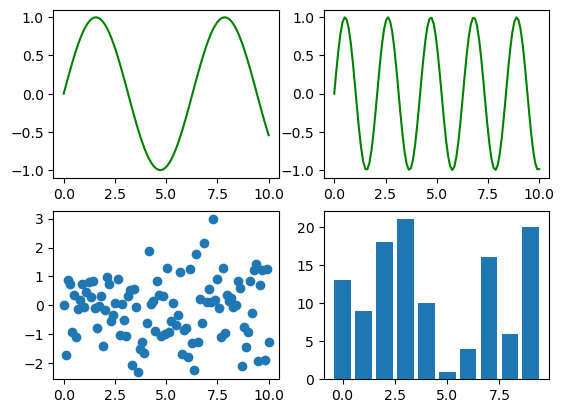

In [27]:
x=np.linspace(0,10,100)
plt.subplot(221) # 2X2的表格 先畫第1個
plt.plot(x,np.sin(x),"g")
plt.subplot(222) # 2X2的表格 先畫第2個
plt.plot(x,np.sin(3*x),"g")
plt.subplot(223) # 2X2的表格 先畫第3個
plt.scatter(x,np.random.randn(100))
plt.subplot(224) # 2X2的表格 先畫第4個
plt.bar(range(10), np.random.randint(1,30,10))

## 6 進階色彩*

#### 顏色表示法 1

    c = 'r' 

可以用 blue (b), green (g), red (r), cyan (c), magenta (m), yellow (y), black (k), white (w)


#### 顏色表示法 2

用一個 0 到 1 的數字表灰階, 越大越白。

    c = '0.6'
    
#### 顏色表示法 3

網頁常用的標準 16 進位 RGB 表示法。

    c = '#00a676'
    
我們怎知哪裡可選顏色呢? 可以用之前彥良介紹的 [Coolors.co](https://coolors.co) 等。
    
#### 顏色表示法 4

用 0-1 的數字表 RGB 也可以。

    c=(0.7, 0.4, 1)

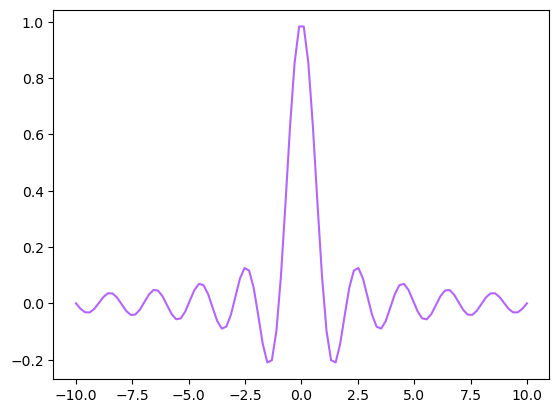

In [29]:
x=np.linspace(-10,10,100)
y=np.sinc(x)
plt.plot(x,y,c=(0.7, 0.4, 1))


## 7 Marker*

所謂 'marker' 就是原來的點, 我們特別標示出來, 為了不要讓圖形太複雜, 我們新換個點比較少的例子。

In [32]:
x=range(20)
y=np.random.randn(20)

range(0, 20)


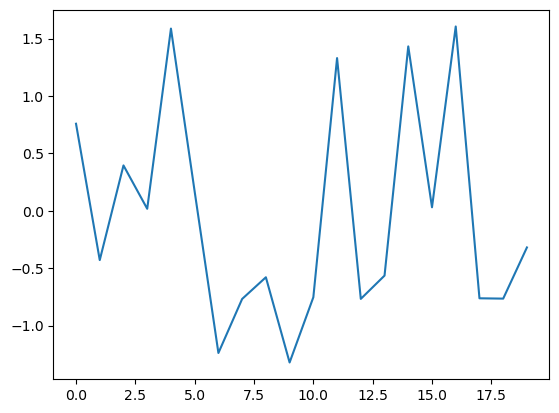

In [33]:
plt.plot(x,y)

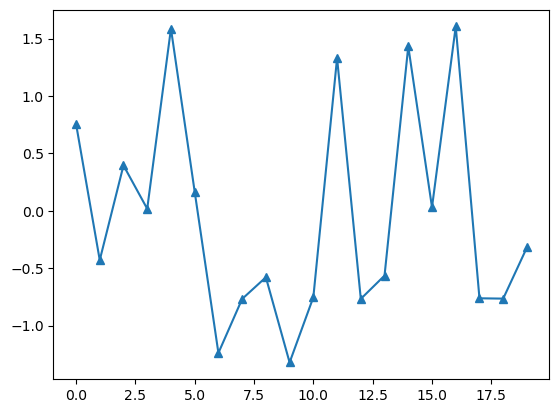

In [34]:
plt.plot(x,y,marker="^")

#### marker 可以設的參數

| 參數 | 說明 |
|---|---|
| `marker` | marker 的風格 |
| `markeredgecolor` (`mec`) | 邊線顏色 |
| `markeredgewidth` (`mew`) | 邊線寬度 |
| `markerfacecolor` (`mfc`) | marker 的顏色 |
| `markerfacecoloralt` (`mfcalt`) | marker 替換色 |
| `markersize` (`ms`) | marker 大小 |
| `markevery` | 隔多少畫一個 marker |

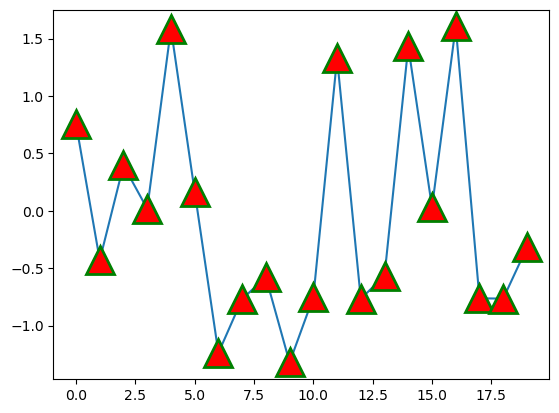

In [35]:
plt.plot(x,y,marker="^",mfc="r",mec="g",mew=2,ms=20)
"""mfc="r" (Marker Face Color)： 標記的「內部填充顏色」。這裡設為 r (紅色 Red)。

mec="g" (Marker Edge Color)： 標記的「外層邊框顏色」。這裡設為 g (綠色 Green)。

mew=2 (Marker Edge Width)： 標記的「邊框粗細」。數字越大，綠色的框線就越粗。

ms=20 (Marker Size)： 標記的「整體大小」。預設值大約只有 6，您直接開到 20，這絕對會是非常搶眼、霸氣外露的巨大西瓜標記！"""

比較奇特的參數是 `markevery`, 這是說我們每多少筆資料要畫一個 marker。為了示範, 我們拿之前的例子來看看。

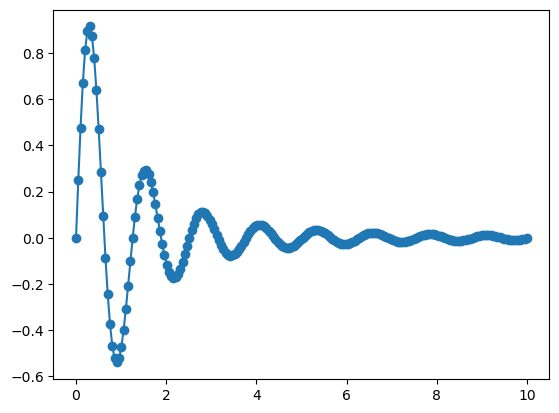

In [43]:
x=np.linspace(0,10,200)
y=np.sin(5*x)/(1+x**2)
plt.plot(x,y,marker="o")

後面的完完全全連在一起了, 我們現在隔 10 個畫一個 marker 試試。

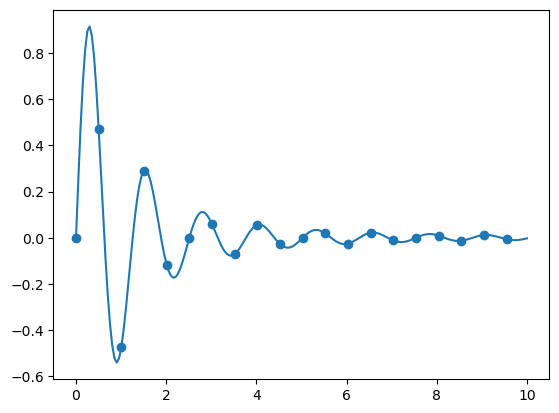

In [42]:
x=np.linspace(0,10,200)
y=np.sin(5*x)/(1+x**2)
plt.plot(x,y,marker="o",markevery=10)

## 8 bar 風*

<BarContainer object of 5 artists>

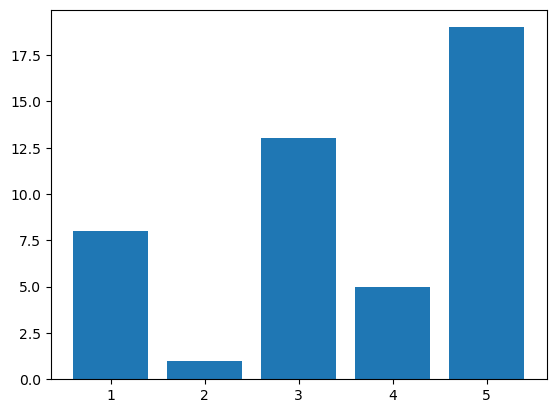

In [44]:
plt.bar(range(1,6),np.random.randint(1,30,5))

移一點點。

<BarContainer object of 5 artists>

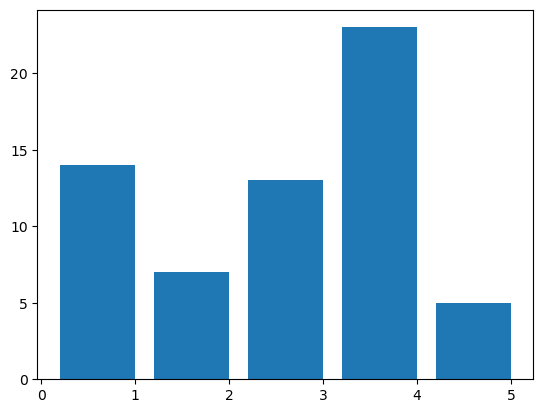

In [52]:
import numpy as np
plt.bar(np.arange(0.6, 5),np.random.randint(1,30,5))


#### 雙色的長條圖

<BarContainer object of 5 artists>

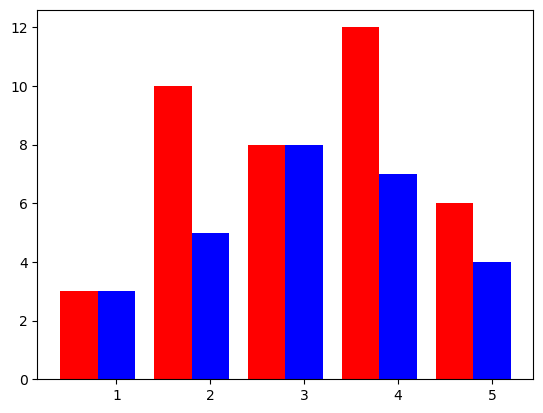

In [58]:
x=np.arange(1,6)
plt.bar(x-0.4, [3,10,8,12,6], color="r",width=0.4)
plt.bar(x, [3,5,8,7,4], color="b",width=0.4)


#### 疊加型的資料

<BarContainer object of 5 artists>

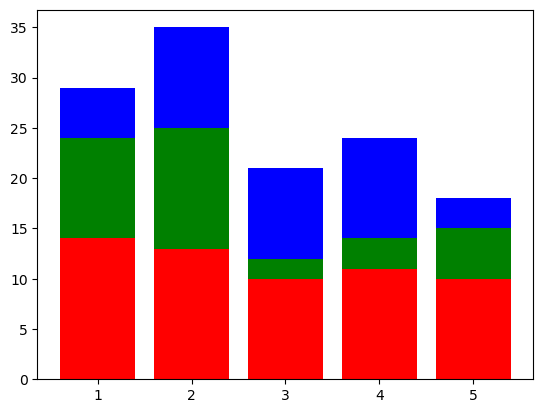

In [61]:
A=np.random.randint(2,15,5)
B=np.random.randint(2,15,5)
C=np.random.randint(2,15,5)

plt.bar(x, A, color="r")
plt.bar(x, B, color="g",bottom=A)
plt.bar(x, C, color="b",bottom=A+B)



#### 橫放的長條圖

<BarContainer object of 5 artists>

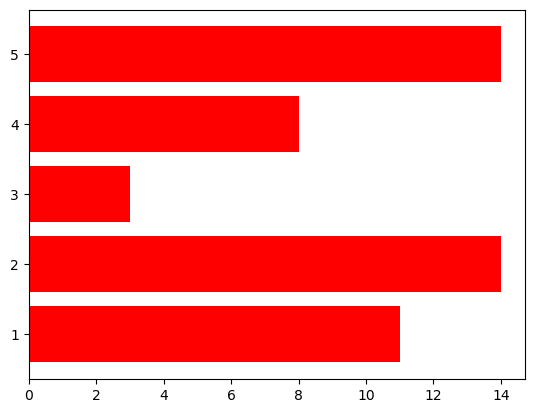

In [62]:
A=np.random.randint(2,15,5)
plt.barh(x, A, color="r")


#### 雙向的長條圖

<BarContainer object of 6 artists>

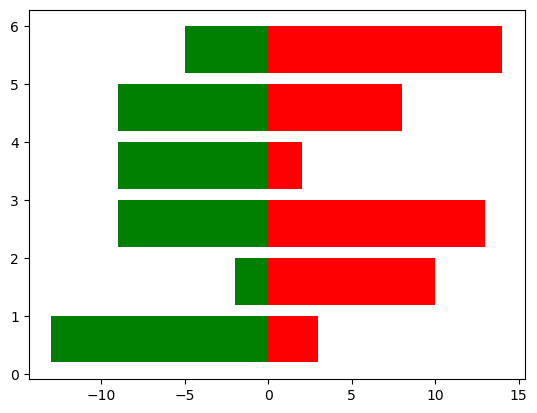

In [66]:
x=np.arange(0.6,6)
A=np.random.randint(1,15,6)
B=np.random.randint(1,15,6)

plt.barh(x, A, color="r")
plt.barh(x, -B, color="g")

## 9 畫圖區的設定*

#### 說明文字的標示

<BarContainer object of 6 artists>

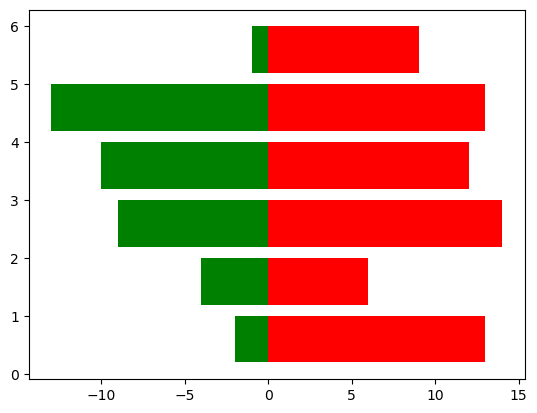

In [67]:
x=np.arange(0.6,6)
A=np.random.randint(1,15,6)
B=np.random.randint(1,15,6)

plt.barh(x, A, color="r")
plt.barh(x, -B, color="g")

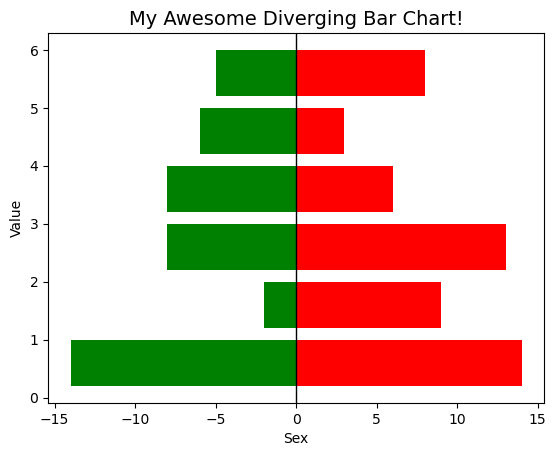

In [71]:
x=np.arange(0.6,6)
A=np.random.randint(1,15,6)
B=np.random.randint(1,15,6)

plt.barh(x, A, color="r")
plt.barh(x, -B, color="g")
plt.title("My Awesome Diverging Bar Chart!", fontsize=14)
plt.xlabel("Sex")
plt.ylabel("Value")
plt.axvline(0, color='black', linewidth=1) # 畫一條 X=0 的垂直黑線


#### 邊界的設定

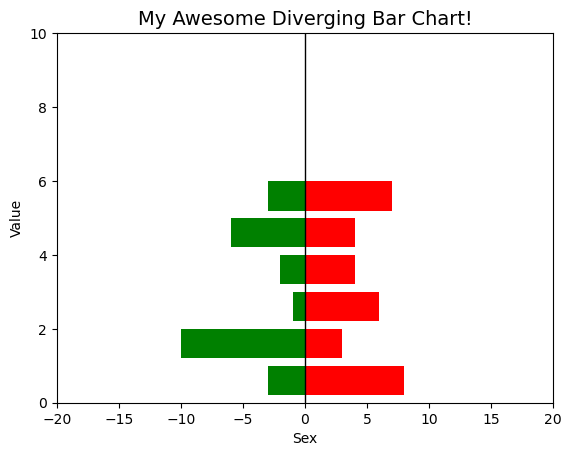

In [74]:
plt.xlim(-20,20)
plt.ylim(0,10)
x=np.arange(0.6,6)
A=np.random.randint(1,15,6)
B=np.random.randint(1,15,6)

plt.barh(x, A, color="r")
plt.barh(x, -B, color="g")
plt.title("My Awesome Diverging Bar Chart!", fontsize=14)
plt.xlabel("Sex")
plt.ylabel("Value")
plt.axvline(0, color='black', linewidth=1) # 畫一條 X=0 的垂直黑線


#### xticks
哇！您現在連 Matplotlib 最精細的**「自訂座標軸刻度 (Ticks)」**都開始挑戰了！畫三角函數時，把 X 軸從單調的數字換成 $\pi$ 的倍數，絕對是展現專業度的最高境界！

([<matplotlib.axis.XTick at 0x21766115450>,
 [Text(0.0, 0, '0'),
  Text(1.5707963267948966, 0, '$\\pi/2$'),
  Text(3.141592653589793, 0, '$\\pi$'),
  Text(4.71238898038469, 0, '$3\\pi/2$'),
  Text(6.283185307179586, 0, '$2\\pi$')])

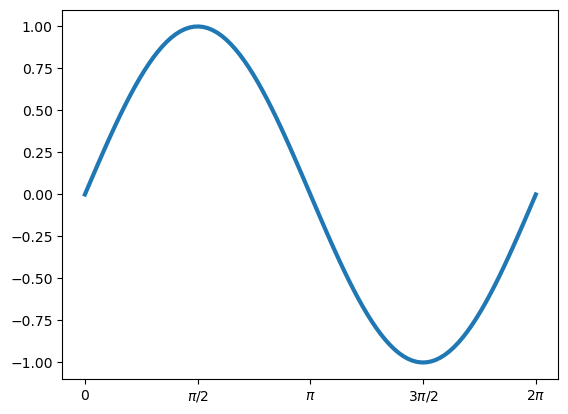

In [77]:

xv=np.linspace(0,2*np.pi,100)
yv=np.sin(xv)
plt.plot(xv,yv,lw=3)
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],['0', '$\pi/2$', '$\pi$', '$3\pi/2$', '$2\pi$'])

# [練習]自己生成測試數據，X軸xticks對應到y軸數值

例如: 1,2,3,4,5 對應X軸 '甲','乙'...

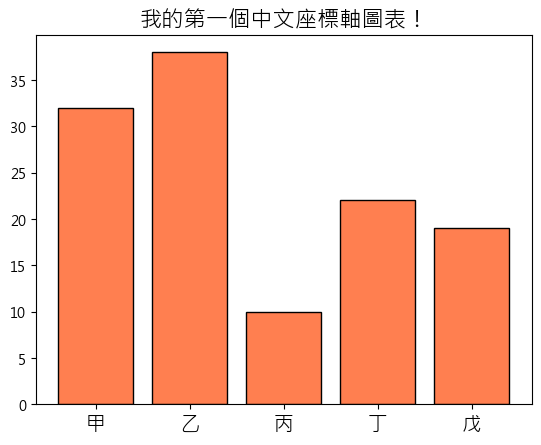

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# 🌟 必備神咒：讓 Matplotlib 支援顯示繁體中文 (Windows 預設用微軟正黑體)
# 如果您是用 Mac，請改成 ['Arial Unicode MS']
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
# 解決座標軸負號顯示成方塊的問題
plt.rcParams['axes.unicode_minus'] = False 

# 1. 生成測試數據
# x 軸的位置：1, 2, 3, 4, 5
x_positions = [1, 2, 3, 4, 5] 
# y 軸的數值：隨機產生 5 個 10 到 50 之間的數字
y_values = np.random.randint(10, 50, 5) 

# 2. 準備我們要替換上的中文標籤
custom_labels = ['甲', '乙', '丙', '丁', '戊']

# 3. 畫出長條圖
plt.bar(x_positions, y_values, color="coral", edgecolor="black")

# 🌟 4. 關鍵魔法：把 X 軸的數字替換成中文！
plt.xticks(x_positions, custom_labels, fontsize=14)

# 加上標題讓圖表更完整
plt.title("我的第一個中文座標軸圖表！", fontsize=16)

# 顯示圖表
plt.show()

#### 圖例 legend

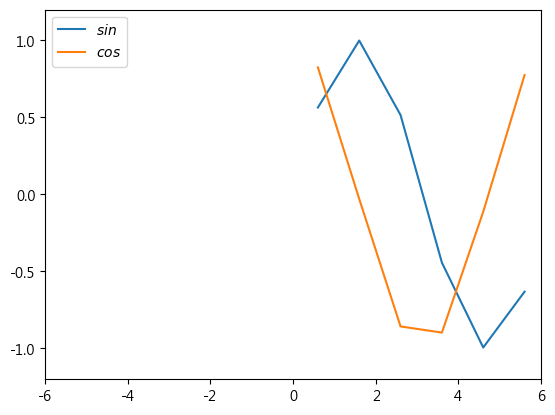

In [86]:
plt.xlim(-6,6)
plt.ylim(-1.2,1.2)
plt.plot(x,np.sin(x),label="$sin$")
plt.plot(x,np.cos(x),label="$cos$")
plt.legend(loc=2)

可用 `loc` 去設圖例的位置, 依 1, 2, 3, ... 表示。

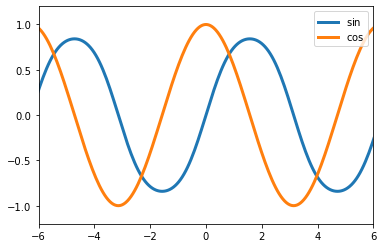

In [60]:
"""# 1. 產生 -6 到 6 之間，共 100 個連續的點
x = np.linspace(-6, 6, 100)

# 2. 設定完美的畫布視野 (X軸與Y軸的極限值)
plt.xlim(-6, 6)
plt.ylim(-1.2, 1.2)

# 🌟 3. 修正：把 sin(y) 改成 sin(x)，並且在字串前面加上 r
plt.plot(x, np.sin(x), label=r"$\sin(x)$", color="blue", lw=2)
plt.plot(x, np.cos(x), label=r"$\cos(x)$", color="red", lw=2, linestyle="--")

# 4. 召喚圖例 (legend)，它會自動抓取上面的 label！
# 內行參數：loc="upper right" 可以強制圖例待在右上角
plt.legend(loc="upper right", fontsize=12)

# 加上標題，大功告成！
plt.title("Sine vs Cosine Waves", fontsize=16)
plt.show()"""

## 10 取得現在工作中 axes*

我們有時要設 axes 的背景啦等等的資訊。這時就要取得現在工作中的 axes。這一般有兩種方式, 第一種是設 `subplot` 時可以取得:

    fig, ax = plt.subplot()
    
另一種是用 `gca` 函數:

    ax = plt.gca()

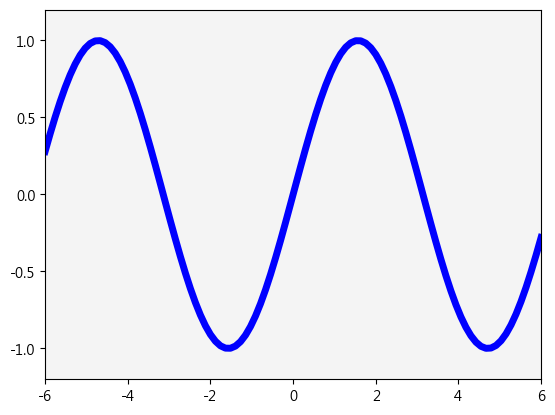

In [93]:
x = np.linspace(-6, 6, 100)
y = np.sin(x)
ax = plt.gca()
ax.set_facecolor("#f4f4f4")
ax.set_xlim(-6,6)
ax.set_ylim(-1.2,1.2)
plt.plot(x, y, lw=5, color="b")


#### 移動 x, y 座標軸

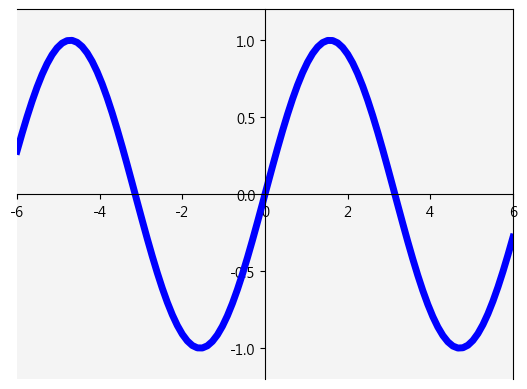

In [95]:
x = np.linspace(-6, 6, 100)
y = np.sin(x)
ax = plt.gca()
ax.set_facecolor("#f4f4f4")
ax.set_xlim(-6,6)
ax.set_ylim(-1.2,1.2)

ax.spines["bottom"].set_position(("data",0))
ax.spines["left"].set_position(("data",0))
plt.plot(x, y, lw=5, color="b")

"""在 Matplotlib 的世界裡，spines（脊椎）指的就是圖表四周的那四條邊框線（上、下、左、右）。

ax.spines["bottom"]：抓出底部的邊框（也就是 X 軸）。

set_position(("data", 0))：這個指令充滿魔法！它告訴 Python：「請把這條邊框從最底下拔起來，移動到真實數據 (data) 的 0 的位置。」
# 🌟 1. 您的神級指令：把下、左邊框移到原點 (0,0) 形成十字
ax.spines["bottom"].set_position(("data", 0))
ax.spines["left"].set_position(("data", 0))

# 🌟 2. 內行隱身術：把上、右邊框的顏色設定為 "none" (透明)
ax.spines["top"].set_color("none")
ax.spines["right"].set_color("none")"""


## 11 耍寶可愛的 `xkcd`*

In [98]:
plt.xkcd()

findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd Script' not found.
findfont: Font family 'Comic Neue' not found.
findfont: Font family 'xkcd' not found.
findfont: Font family 'xkcd S

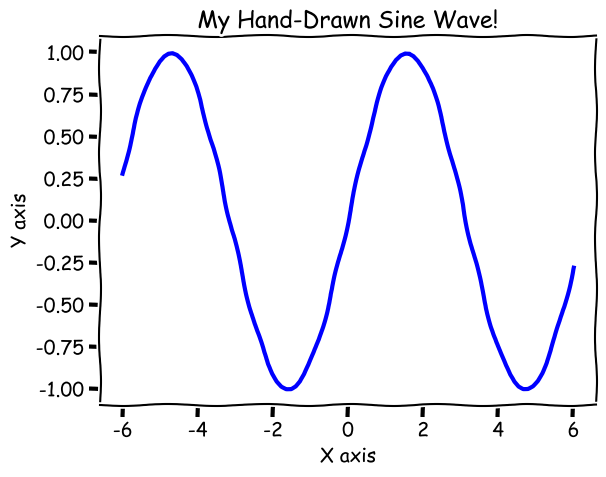

In [101]:
x = np.linspace(-6, 6, 100)
y = np.sin(x)
with plt.xkcd():
    plt.plot(x, y, color="blue", lw=3)
    plt.title("My Hand-Drawn Sine Wave!")
    plt.xlabel("X axis")
    plt.ylabel("Y axis")
    plt.show()

## 12 `seaborn` 大救星

雖然 `matplotlib` 幾乎什麼都可以調, 但有些簡單的調整卻要花費很多時間。於是有了許多可以協助 `matplotlib` 變美、變方便的套件出現。最近有個很有名的叫 `seaborn`, 儼然有另一個標準套件的態式。

最重要的是 `seaborn` 和我們未來要介紹的 `pandas` 配合得非常好, 雖然熊貓和海生的聽來就沒什麼關係...

我們先來個標準 (又來標準縮寫) 讀入 `seaborn` 的方法。

In [107]:
import seaborn as sns
plt.rcdefaults()

然後像平常畫個圖。

In [108]:
sns.set(color_codes=True)

<Axes: >

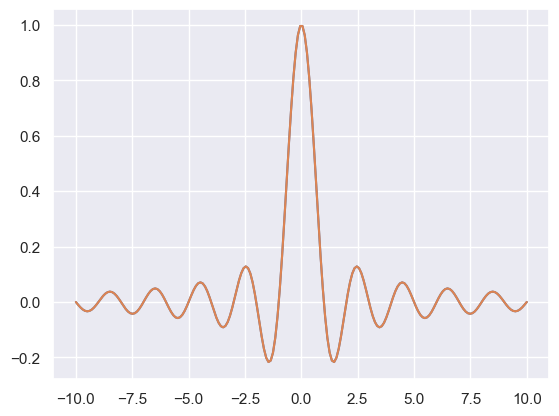

In [111]:
x=np.linspace(-10,10,200)
y=np.sinc(x)

plt.plot(x,y)
sns.lineplot(x=x, y=y)

傑克, 這真是太神奇了!

總之, 你根本就直接用原來 `matplotlib` 的指令, 馬上 `seaborn` 就會幫你美化。當然我們還是可以做更多的控制, 詳情請參考

[seaborn 的網站](https://seaborn.github.io/)